# Relational Derivation Tables

This notebook serves to illustrate the creation of relational derivation tables, and a range of applications based on automated relational derivation leveraging the derivation tables.

### Content
1. Creating derivation tables
2. Automated relational derivation in relational networks
3. Visualizing relational networks
4. Creating syllogistic reasoning tasks
5. Creating matching-to-sample procedures

### How to use this notebook?
1. Run Cell 2 to load dependencies and function
2. Adapt the 'relations' as per your wishes in Cell 3 and run the function
3. Run Cell 4 to print out the tables for mutual and combinatorial entailment
4. Run Cell 5 to plot the tables as heatmaps.


In [1]:
# Dependencies
import numpy as np
from createDerivationTables import createDerivationTables # function that creates derivation tables for a specified set of relations
from deriveRelationsFromBaseline import deriveRelationsFromBaseline # function to derive relations from input relations
from utils import *
from plot_utils import *

### Default Relational Derivation Tables

Run the cell below to create the default derivation tables, including all currently supported relations.

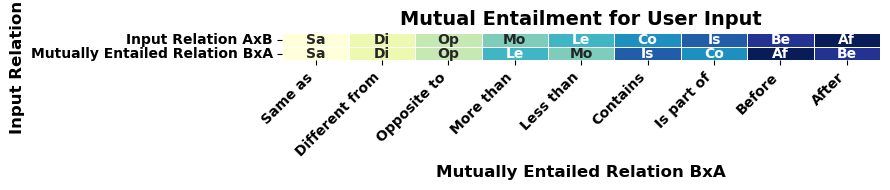

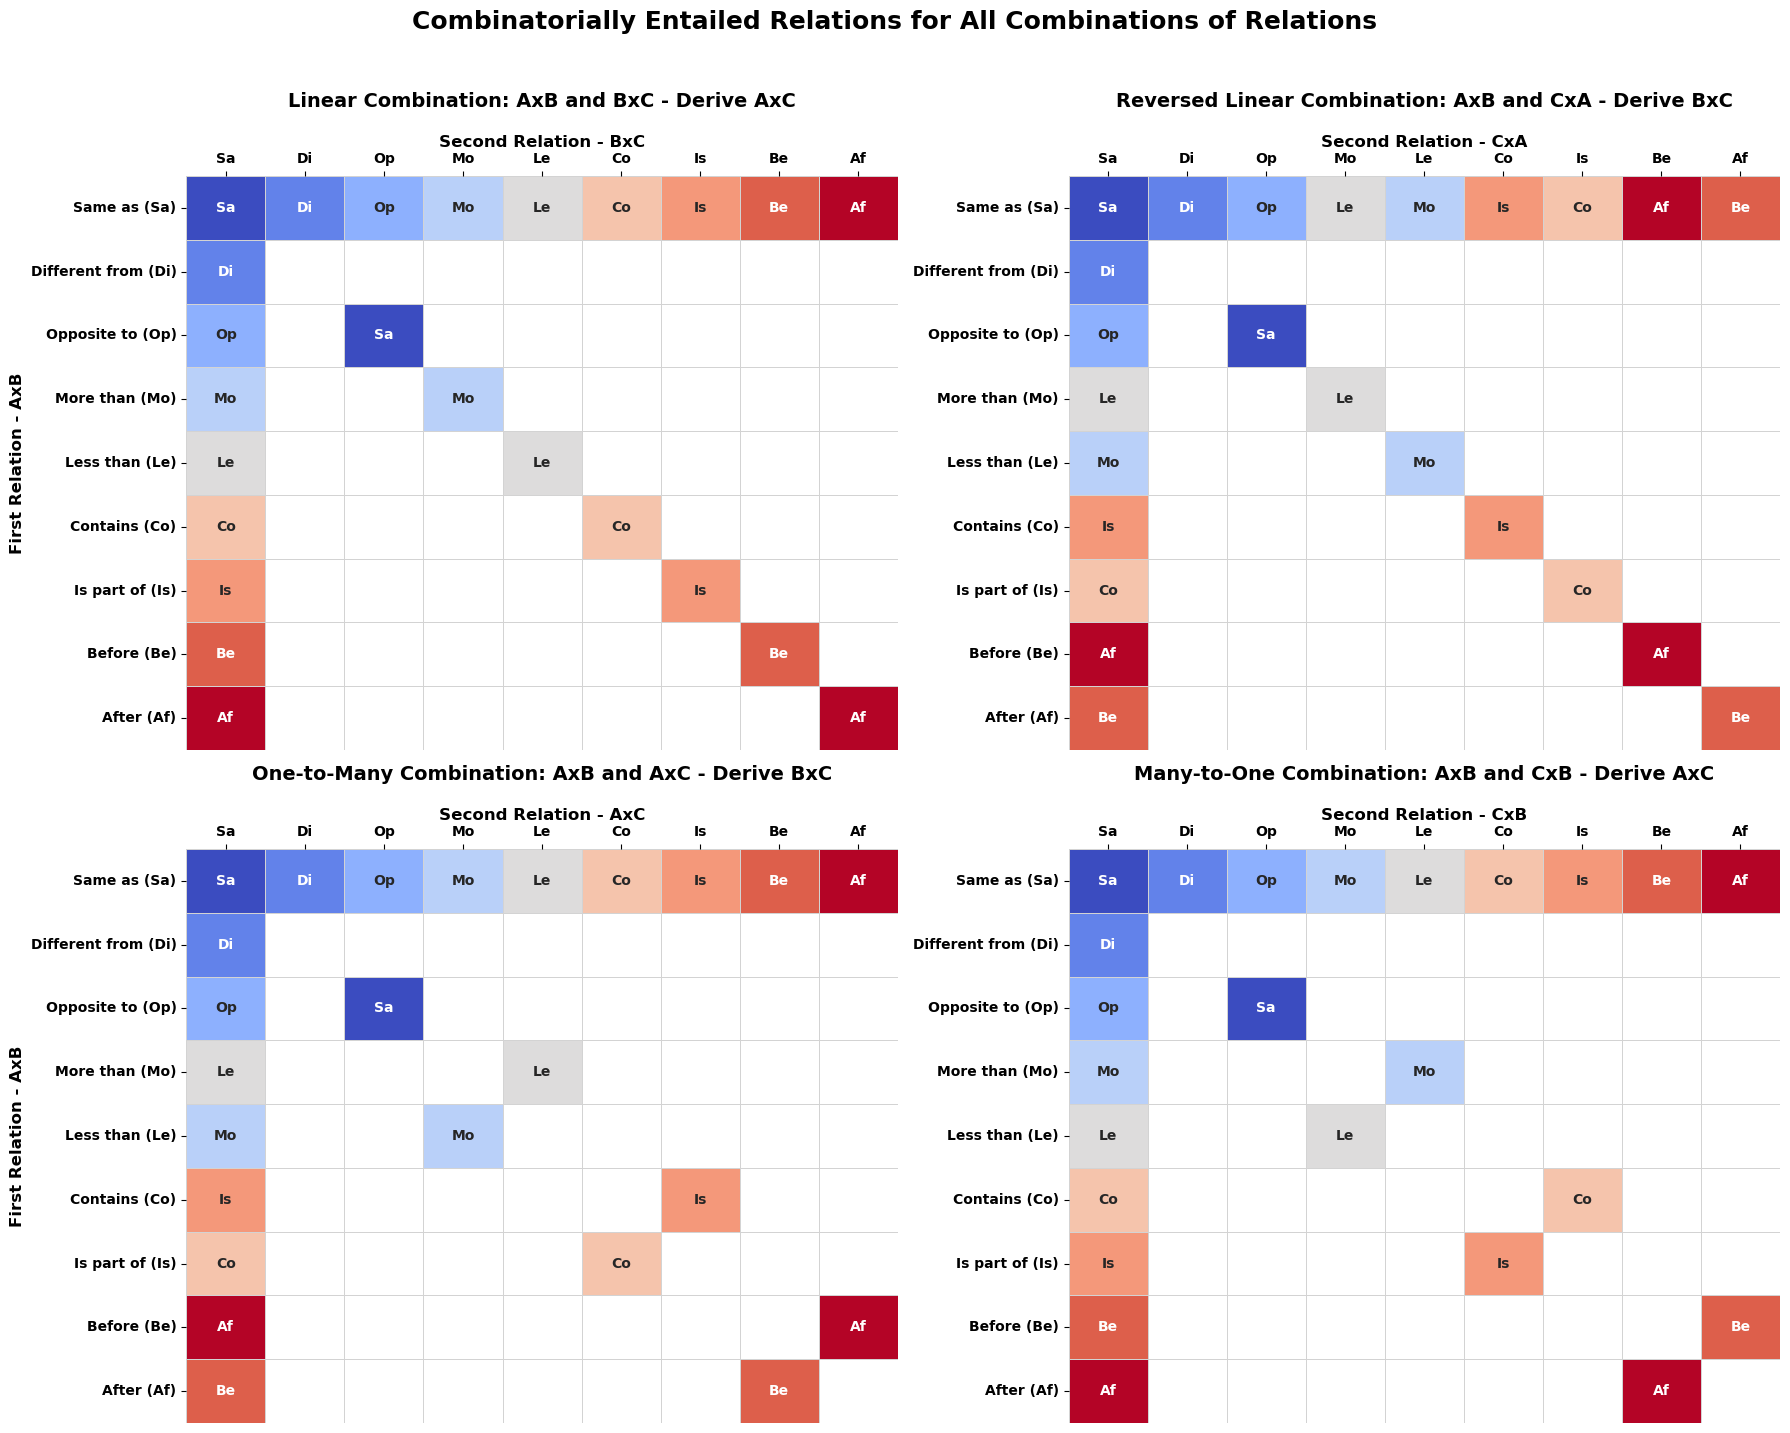

In [2]:
# Run function to create (default) tables (no relations specified)
mutual, combi, relations = createDerivationTables(plotTables = True) # plotTables = True to also plot the resulting tables 

### User-specified Relational Derivation Tables

Users can also choose the relations they want to be included in the derivation tables. A range of relations is supported, making use of the fact that many relations (e.g., taller, longer, smaller) are specific example of more general patterns of derivation (e.g., more than and less than).

To print out the full set of supported relations, run the line of code in the next cell. Otherwise, specify the relations you wish to include in the cell below that.


Supported general patterns of relations:
- Same as
- Different from
- Opposite to
- More than
- Less than
- Contains
- Is part of
- Before
- After

For example:
relations = ['Same as', 'More than', 'Less than']

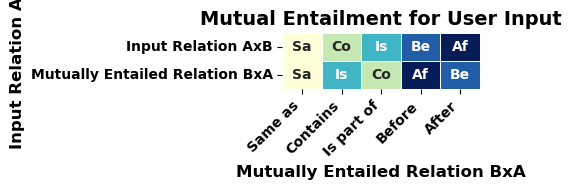

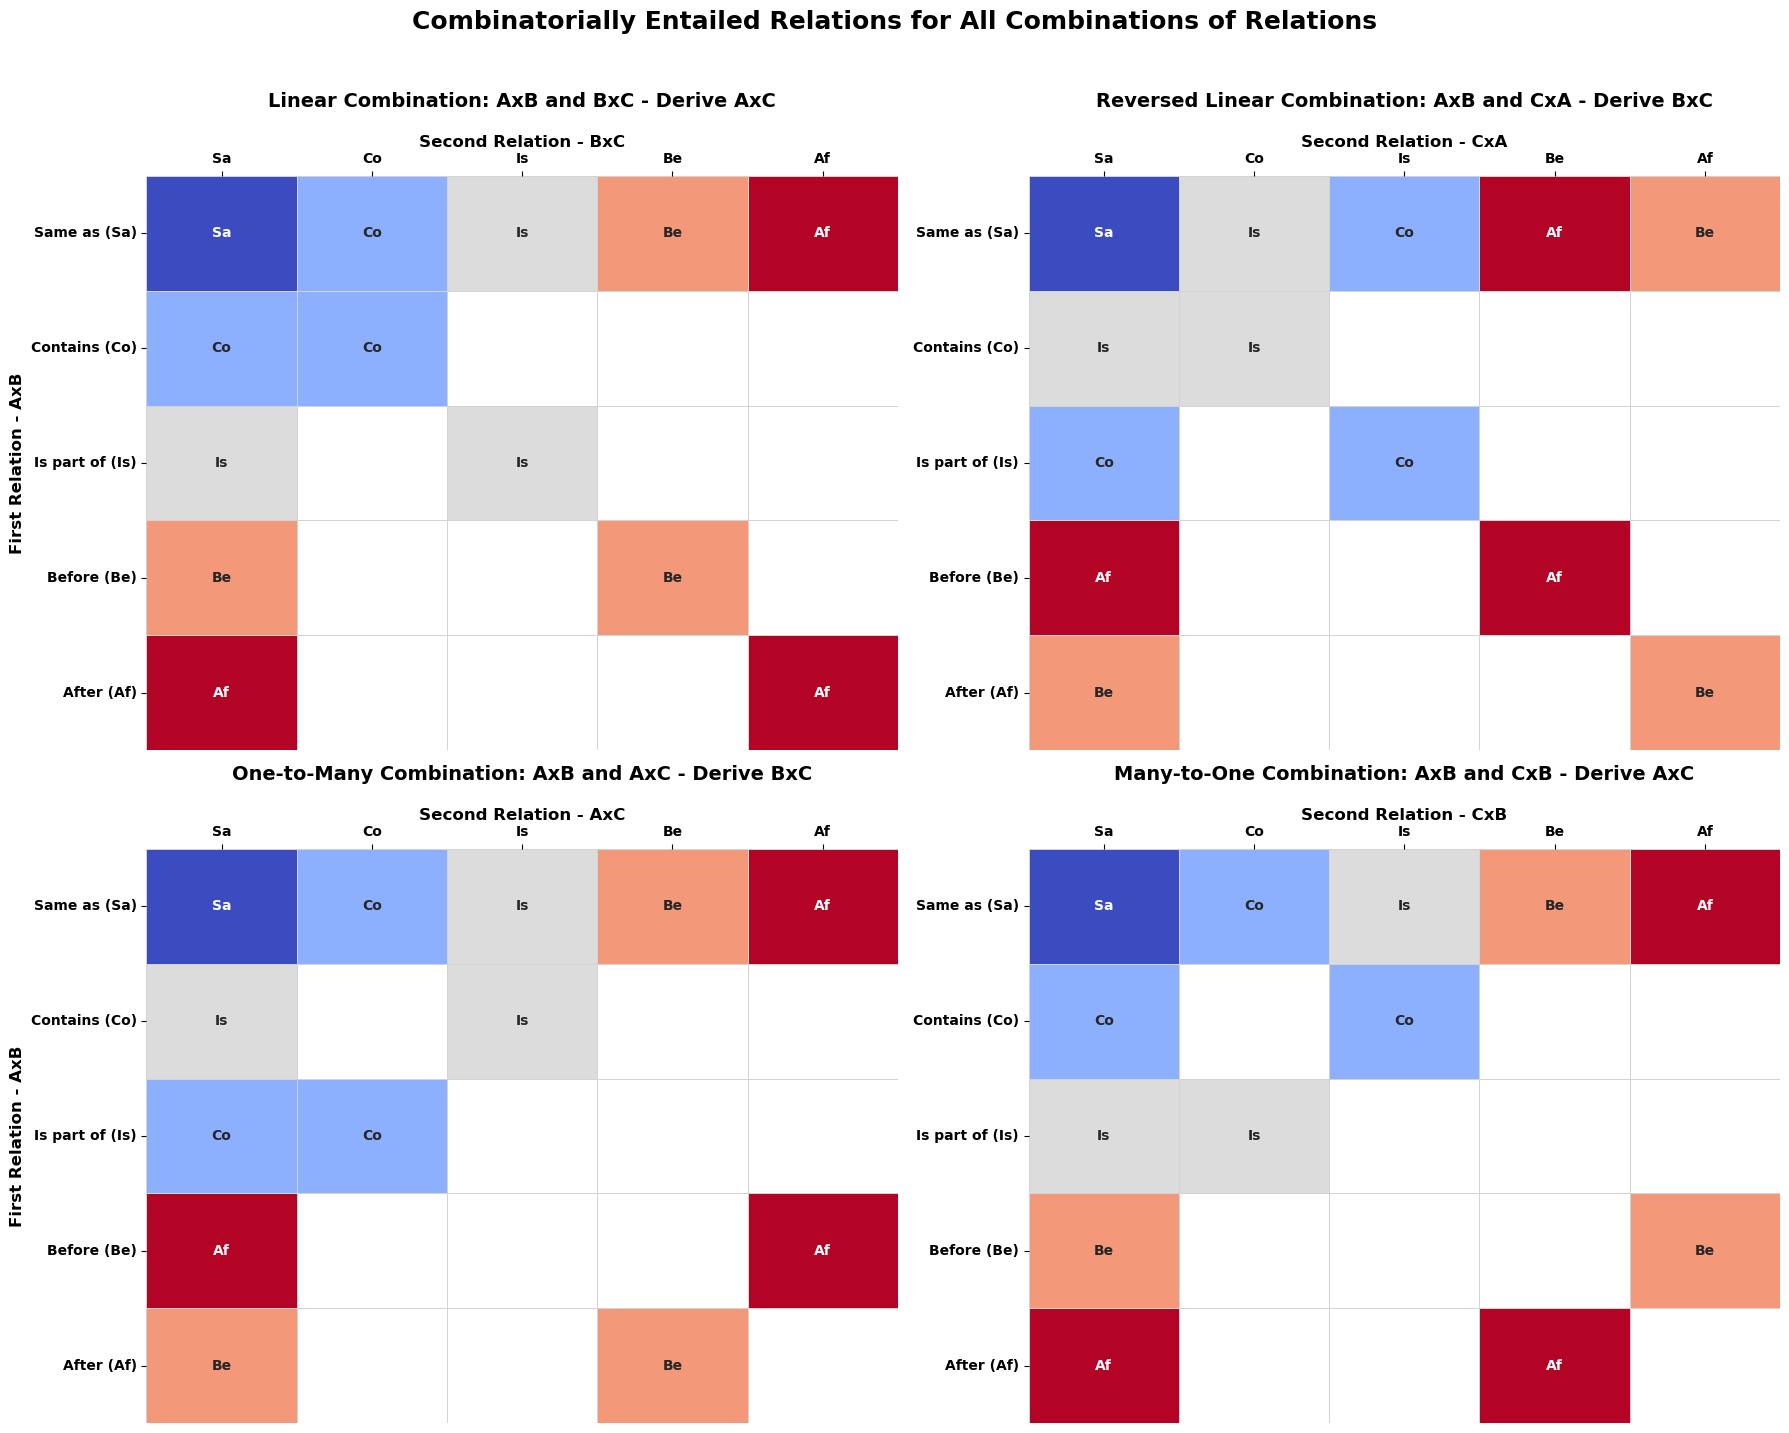

In [3]:

# Specify list of relations to create specific derivation tables
relations = []
# for example, relations = ['Same as', 'Contains', 'Is part of', 'Before', 'After']

mutual, combi, relations = createDerivationTables(relations, plotTables = True)



### Function Flexibility 

Users can also specify specific instances of these more general relations. For instance, to create typical syllogistic reasoning problems (e.g., 'Ben is taller than Mary, Mary is taller than Eve. Is Ben taller than Eve?')

As you might notice, the function will complete the set of relations input by the user to ensure all derivations are included in the output. For example, if the user only specifies 'more than', the mutually entailed 'less than' will be included automatically.


Run the cel below for an example.

In [ ]:
relations = ['taller', 'weaker']

mutual, combi, relations = createDerivationTables(relations, plotTables = True)


### Comparing Patterns of Derivation for Different Sets of Relations

Above, I already noted that the derivation tables make use of the fact that many relations (e.g., ones we use in day-to-day languagecan be thought of as specific instances (e.g., taller, longer) of more general patterns of derivation (e.g. more than and less than).

RFT generally describes different relational frames as distinct patterns (or families) of relational responding (i.e., patterns of mutual and combinatorial entailment and transformation of function), like the coordination and distinction frame, comparative relations, temporal relations, and so on. 

While this distinction in RFT is mostly a pragmatic one and the question of which (or how many) frames actually can be distinguished does not necessarily bear particular theoretical importance, the derivation tables do seem to suggest that the structure RFT proposes may not be the most parsimoneous one.

For example, running the next block of code illustrates that when we separately plot the comparative (more than, less than) and temporal (before, after) relations, it becomes apparent that they have the exact same patterns of derivations. 

Derivation Tables for Comparative Relations


C:\Users\mraemaek\OneDrive\Documenten\UGent stuff\Ghent_PhD\Projects\Modelling\DerivationTableApplications\Scripts\plot_utils.py:113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


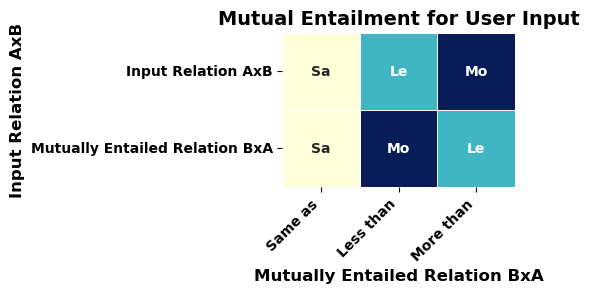

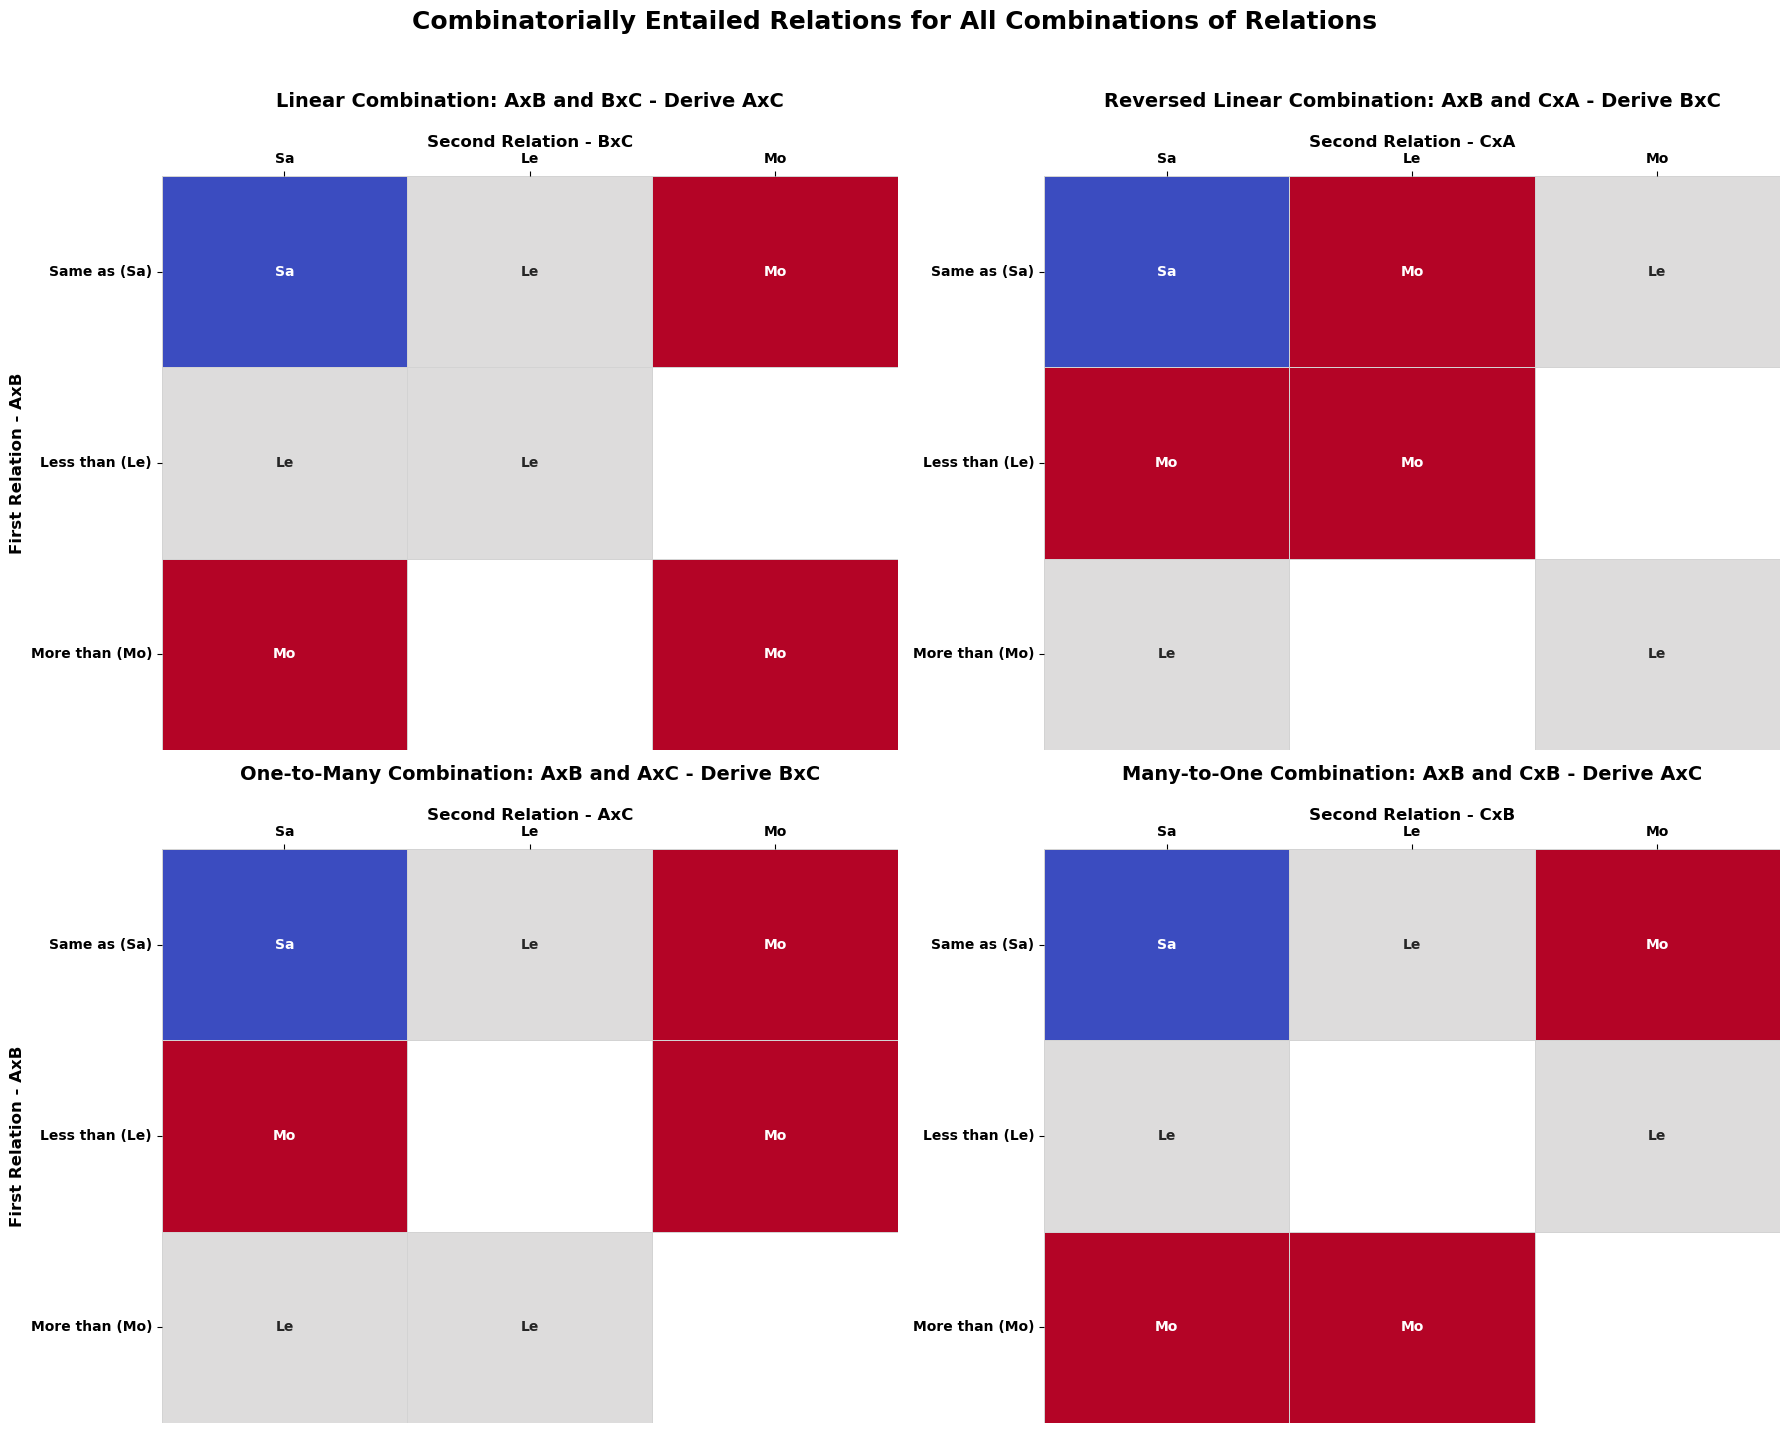

Derivation Tables for Temporal Relations


C:\Users\mraemaek\OneDrive\Documenten\UGent stuff\Ghent_PhD\Projects\Modelling\DerivationTableApplications\Scripts\plot_utils.py:113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


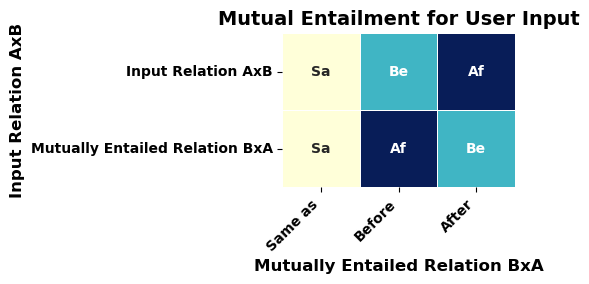

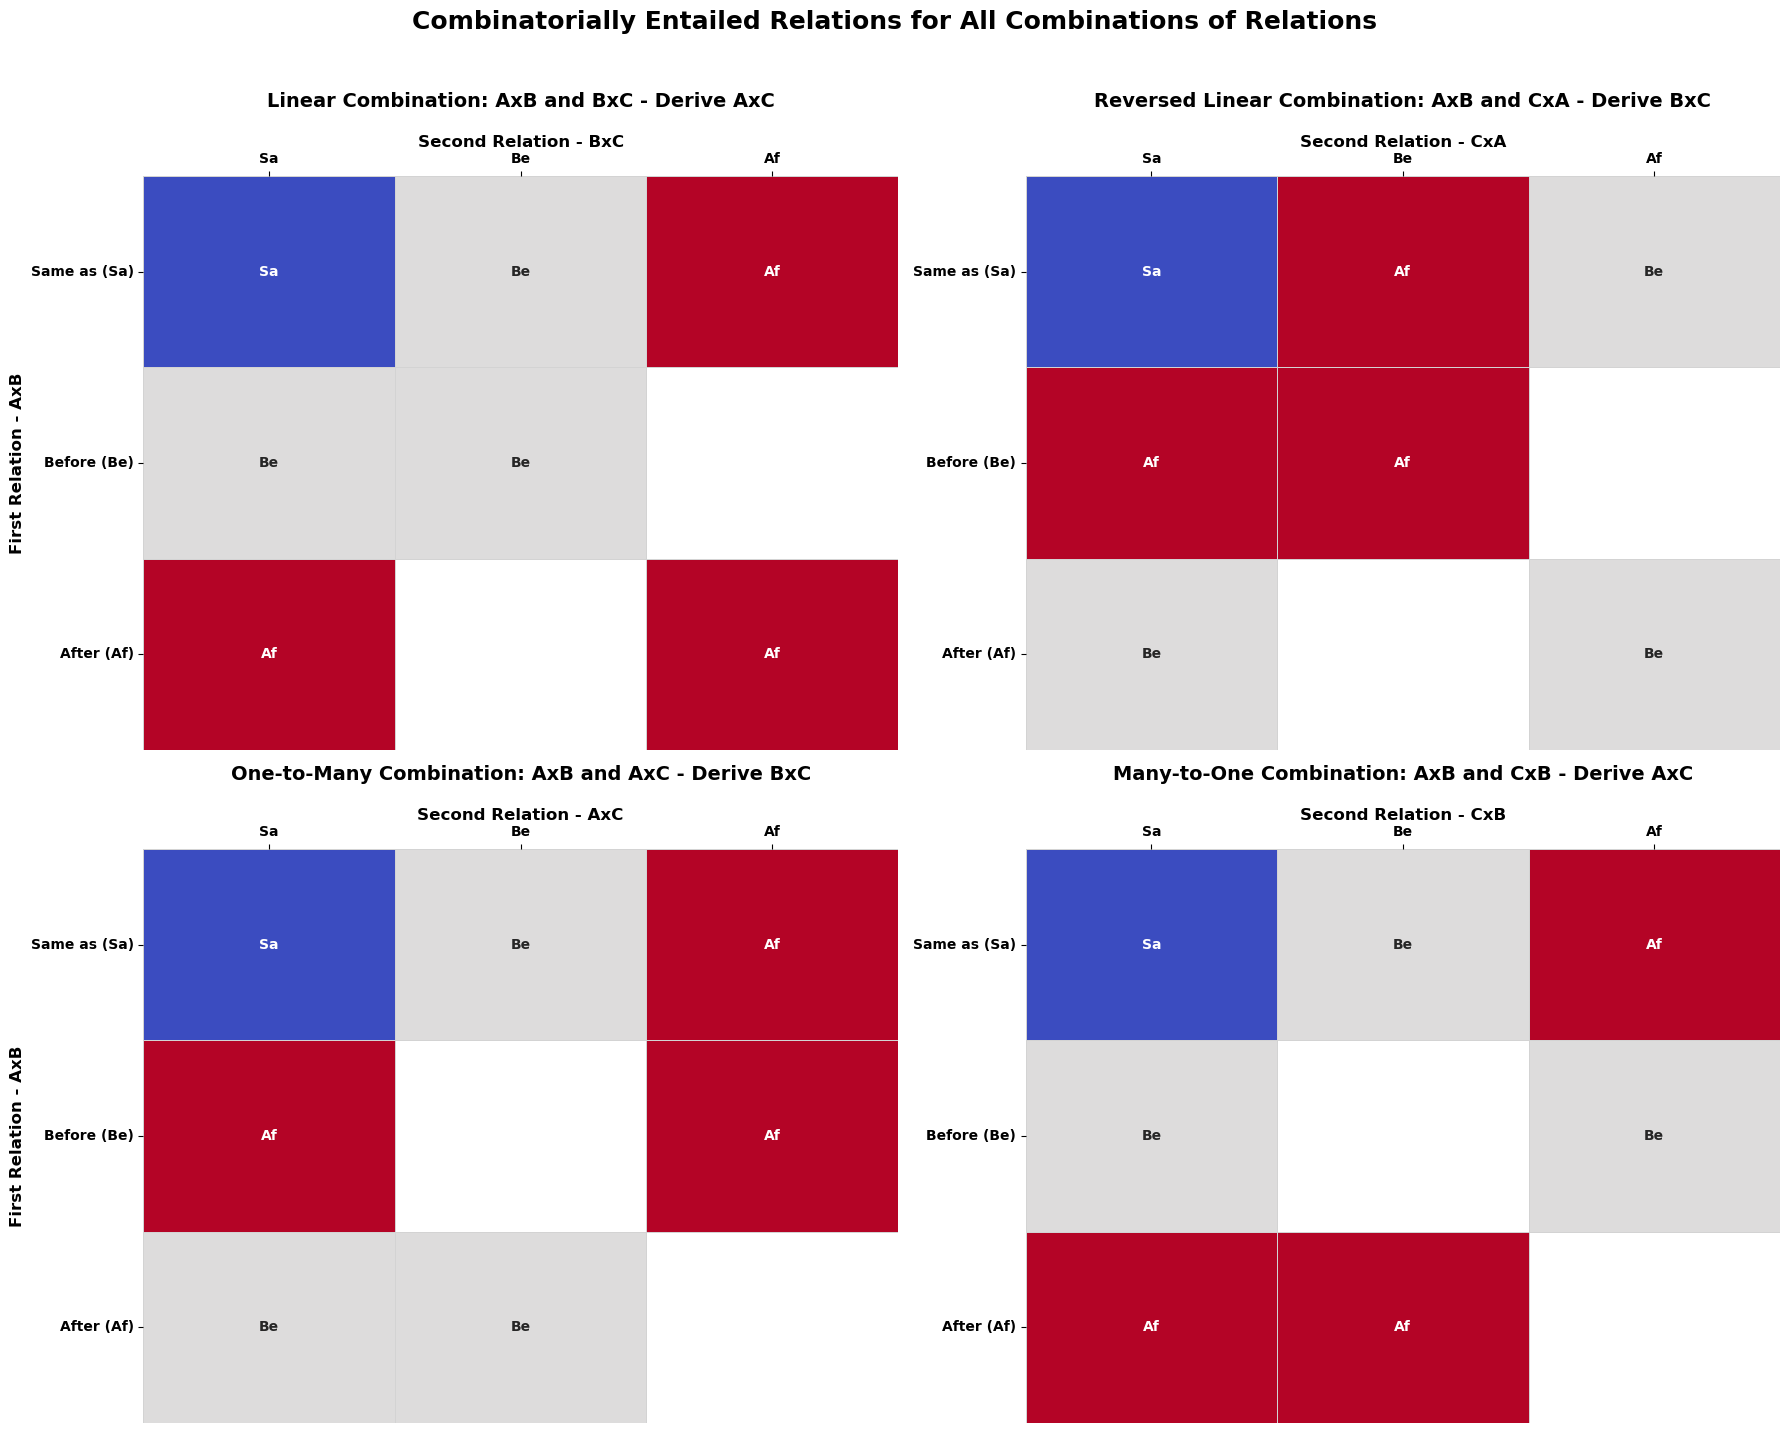

In [3]:
relations = ['Same as', 'Less than', 'More than']
print('Derivation Tables for Comparative Relations')
mutual, combi, relations = createDerivationTables(relations, plotTables = True)

relations = ['Same as', 'Before', 'After']
print('Derivation Tables for Temporal Relations')
mutual, combi, relations = createDerivationTables(relations, plotTables = True)

# Automatic Derivation in Relational Networks

These derivationa tables, interesting as they are, are merely the backbone for a range of applications. 
The tables allow for automating relational derivation. That is, when a(n) (set of) relation(s) is provided, the derivation tables can be used as look-up tables to find all relations that can be derived from the (combination of) the source relation(s). 

Human relational reasoning is extremely generative, in that learning about n relations allows one to derive up to n² novel relations (the exact number depends on which particular relations are involved, some can be combined in more ways). This generativity often complicates the task of researchers who wish to study relational reasoning, as the relational networks involved in a task quickly become very large and hard to visualize.

The function illustrated below is designed to facilitate relational reasoning research by addressing those particular challenges. Provided a set of baseline relations, it automatically finds all derived relations. The resulting network can then be illustrated as a heatmap, or as a graph network.

To test the function, run the code in the cell below. All it does is specify some stimulus labels (A, B1, B2, ...) and six baseline relations that hold between those stimuli (similar to Steele & Hayes, 1991):
    - A same as B1
    - A same as C1
    - A different from B3
    - A different from C3
    - A opposite to B2
    - A opposite to C2

Note: the baseline relations are defined as a python dictionary, in which the keys represent the relations, and for each relation, a list of tuples represents the different instances (i.e., pairs of related stimuli) of that relation.

The function allows for different visualisations of the derivations. The simplest one is to merely print out each of the derivations (note that this will get chaotic as the number of relations increases).


In [2]:
# Using such derivation tables, user can automatically derive relations from
# a specific set of baseline relations

# For instance, if we provide some stimulus labels, we can recreate the network
# trained by Steele & Hayes, with six baseline relations:
    # A same as B1; A same as C1;
    # A different from B3, A different from C3;
    # A opposite to B2, A opposite to C2
    
sLabs = ['A', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'N1', 'N2']
baseline = dict({'Same as': [(0,1), (0,4)],
             'Different from': [(0,3), (0,6)],
             'Opposite to': [(0,2), (0,5)]})

illustrate = 'print' # print derivations
relTab, derived = deriveRelationsFromBaseline(baseline, sLabs, illustrate)



A is Same as B1 
and A is Same as C1.                                           
From that, I can derive that B1 is Same as C1.

...And that C1 is Same as B1.


A is Same as B1 
and A is Different from B3.                                           
From that, I can derive that B1 is Different from B3.

...And that B3 is Different from B1.


A is Same as B1 
and A is Different from C3.                                           
From that, I can derive that B1 is Different from C3.

...And that C3 is Different from B1.


A is Same as B1 
and A is Opposite to B2.                                           
From that, I can derive that B1 is Opposite to B2.

...And that B2 is Opposite to B1.


A is Same as B1 
and A is Opposite to C2.                                           
From that, I can derive that B1 is Opposite to C2.

...And that C2 is Opposite to B1.


A is Same as C1 
and A is Same as B1.                                           
From that, I can derive that C1 is Same as B1.



Instead of printing out all derivations, we can also visualize the relational network (baseline and derived relations) as a stimulus-by-stimulus heatmap. The function will create a heatmap for each relation, and the color of the cells represent whether the two stimuli (on those coordinates) are related (green) or not (red).

In this example of the Steele and Hayes (1991) network, you can see the baseline relations on the top row of each plot (heatmap), and derived relations on all other rows.

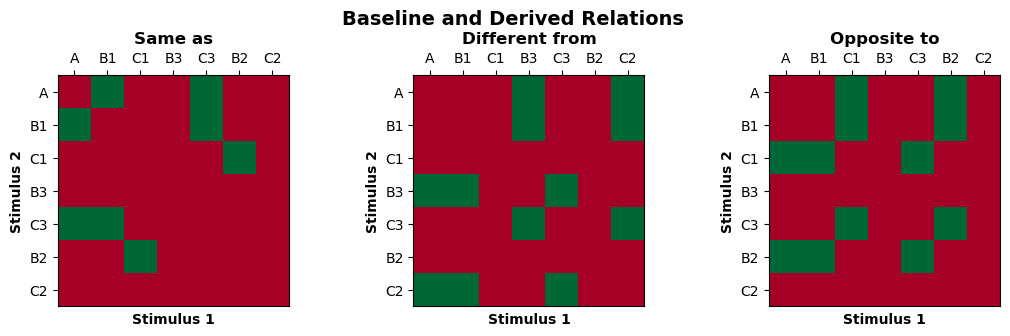

In [3]:
# Instead of printing out the derivations, you can plot the network as a heatmap
illustrate = 'heatmap'
relTab, derived = deriveRelationsFromBaseline(baseline, sLabs, illustrate)


In [ ]:
# Alternatively, we can plot the network as a graph

plotRels = ['baseline', 'mutual', 'combi'] # which relations to plot
plotTitle = '' # optional title
sLabs = ['A', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'N1', 'N2']

# Deinfe baseline network
baseline = dict({'Same as': [(0,1), (0, 4)],
                  'Different from': [(0,2), (0,5)], 
                'Opposite to': [(0,3), (0,6)]
             })
illustrate = 'graph'
relTab, derived = deriveRelationsFromBaseline(baseline, sLabs, illustrate)


### Transitive Inference

Using this same logic, we can also create and visualize a typical transitive inference task. 

In such procedures, participants are trained on a series of discriminations A>B, B>C, C>D, D>E, E>F. After training, they are tested on discriminations of non-adjacent pairs (e.g., AF, BE). For the edge nodes AF, the discrimination is straightforward as A was always reinforced, and F was never reinforced. For other pairs like BE, however
But, to do that properly, one needs multi-step derivation

In [ ]:
# Or we could do a typical  transitive inference task

# 

sLabs = ['A', 'B', 'C', 'D', 'E', 'F']
baseline = {'More than': [(0,1), (1,2), (2,3), (3,4), (4,5)]}

relTab, derived = deriveRelationsFromBaseline(baseline, sLabs, illustrate)
